## **Flash Drought Detection based on Evaporative Stress Ratio (ESR)**

### **What are Flash Drought (FD) Events?**

- Flash droughts are droughts that **develop rapidly over a short period**, characterized by a **sudden** and **intense onset**, often driven by **high temperatures** and **lack of precipitation**.

![sample_data/FD_example_Otkin.jpg](https://github.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/blob/main/sample_data/FD_example_Otkin.jpg?raw=1)

**Credit:** Otkin *et al.* (2018), *BAMS* ; https://doi.org/10.1175/BAMS-D-17-0149.1

---

### **How to Detect Flash Drought Events?**

![sample_data/flash_drought_methodology_Christian_JHM_2019.jpg](https://github.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/blob/main/sample_data/flash_drought_methodology_Christian_JHM_2019.jpg?raw=1)

**Credit:** Christian *et al.* (2019), *Journal of Hydrometeorology* ; https://doi.org/10.1175/JHM-D-18-0198.1

---

## **Evaporative Stress Ratio (ESR)**

The Evaporative Stress Ratio is defined as:

$$
ESR = \frac{ET}{PET}
$$

**where:**

- **$ET$** = Actual Evapotranspiration  
- **$PET$** = Potential Evapotranspiration  

---

## **Priestley-Taylor Based Potential Evapotranspiration**

Potential evapotranspiration (PET) can be calculated using different methods.  
Here we use the **Priestley-Taylor method**, expressed as:

$$
PET = \alpha_{PT}
\frac{\Delta}{\Delta + \gamma}
\left( R_n - G \right)
$$

**where:**

- **$\alpha_{PT}$** = Priestley-Taylor coefficient  
- **$\Delta$** = slope of saturation vapor pressure curve  
- **$\gamma$** = psychrometric constant  
- **$R_n$** = net radiation  
- **$G$** = soil heat flux  

---


## **Let's understand this with the data**

# **Let's Download Input Data from Google Drive**

In [4]:
import os
from google.colab import drive
import subprocess
# Data 1
data_dir = "Sample_Input_Data_CE_491"
file_name = "daily_data_UA-Var_2000_2021_FD.csv"
os.makedirs(data_dir, exist_ok=True)
drive_url = "https://drive.google.com/file/d/1xAJuO4F1XpyU14n8xeu9FB3Piybxmd-K/view?usp=sharing"
folder_id = "1xAJuO4F1XpyU14n8xeu9FB3Piybxmd-K"
#!gdown --folder https://drive.google.com/drive/folders/{folder_id} -O {data_dir} # When downlaoding a directory
!gdown https://drive.google.com/uc?id={folder_id} -O {data_dir}/{file_name}    # Single File

# Data 2
file_name = "fitted_alpha_PT_params.csv"
drive_url = "https://drive.google.com/file/d/1E8xal55gvM3VnmvgU_I9_9sLu6AogboT/view?usp=sharing"
folder_id = "1E8xal55gvM3VnmvgU_I9_9sLu6AogboT"
!gdown https://drive.google.com/uc?id={folder_id} -O {data_dir}/{file_name}
print(f"Data downloaded to: {os.path.abspath(data_dir)}")

Downloading...
From: https://drive.google.com/uc?id=1xAJuO4F1XpyU14n8xeu9FB3Piybxmd-K
To: /content/Sample_Input_Data_CE_491/daily_data_UA-Var_2000_2021_FD.csv
100% 1.49M/1.49M [00:00<00:00, 48.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1E8xal55gvM3VnmvgU_I9_9sLu6AogboT
To: /content/Sample_Input_Data_CE_491/fitted_alpha_PT_params.csv
100% 97.7k/97.7k [00:00<00:00, 11.9MB/s]
Data downloaded to: /content/Sample_Input_Data_CE_491


In [5]:
def calc_PET_priestley_taylor(tmean,rn,g,pressure,alpha):
    """Potential evapotranspiration calculated according to
    :cite:t:`priestley_assessment_1972`.

    Parameters
    ----------
    tmean: pandas.Series or xarray.DataArray
        air temperature [degC].
    rn: float or pandas.Series or xarray.DataArray
        net radiation [W m-2].
    g: float or pandas.Series or xarray.DataArray
        soil heat flux [W m-2].
    pressure: float or pandas.Series or xarray.DataArray
        atmospheric pressure [kPa].
    alpha: float
        calibration coefficient [-].

    Returns
    -------
    pandas.Series or xarray.DataArray containing the calculated pootential
    evapotranspiration [W m-2].

        Notes
    -----

    .. math:: PET = \\frac{\\alpha_{PT} \\Delta (R_n-G)}
        {\\(\\Delta +\\gamma)}
    """
    gamma = calc_psy(pressure)
    dlt = calc_vpc(tmean)
    pet = (alpha * dlt * (rn - g)) / ((dlt + gamma))
    pet = clip_zeros(pet, clip_zero=True)
    return pet

In [11]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
alpha_PT_df = pd.read_csv("Sample_Input_Data_CE_491/fitted_alpha_PT_params.csv")  # Data with optimized alpha for PET calculation
site = "US-Var"

In [8]:
# Load flux data
df = pd.read_csv("Sample_Input_Data_CE_491/daily_data_UA-Var_2000_2021_FD.csv")
df.replace(-9999, np.nan, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,LE_F_MDS,H_F_MDS,TA_F,PA_F,VPD_F,NETRAD,G_F_MDS,LAI,GPP_NT_VUT_REF,SW_IN_F,theta_2,WS_F,LW_IN_F,fPAR,PET
Date,,,,,,,,,,,,,,,
2000-01-01,19.570816,20.027916,5.081646,99.678875,0.855792,39.598732,0.000000,0.932972,1.772063,80.142542,NaN,1.085375,291.724792,0.523084,27.440970
2000-01-02,28.721393,16.247169,4.023729,100.444396,1.306938,44.968562,0.000000,0.943252,1.421029,112.607146,NaN,0.927312,273.736958,0.527842,31.765450
2000-01-03,26.565773,16.962246,5.921458,100.943687,2.717104,43.528020,0.000000,0.951907,1.621972,116.064208,NaN,1.052146,274.182333,0.532215,33.076668
2000-01-04,19.570816,20.027916,6.048417,100.984083,1.944479,39.598732,0.000000,0.959523,1.854575,64.602021,NaN,0.852604,297.051917,0.536306,29.120537
2000-01-05,28.721393,16.247169,6.881250,100.390875,4.226750,44.968562,0.000000,0.966685,1.662609,123.265271,NaN,1.604437,260.530542,0.540216,36.562440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,21.209994,10.610643,5.610792,98.979563,0.134000,31.820637,-4.322500,1.395609,-0.275779,48.185521,NaN,2.513250,320.516042,0.672120,22.170202
2021-12-28,21.328107,7.597259,4.777333,98.922562,1.347938,28.925366,-8.257254,1.394930,-0.913702,75.071271,NaN,1.366229,307.204500,0.673861,20.189273
2021-12-29,25.450981,2.610954,5.727437,98.627437,0.623313,28.061934,-8.024530,1.385167,-0.794307,23.967229,NaN,2.021438,329.588833,0.672651,22.181335


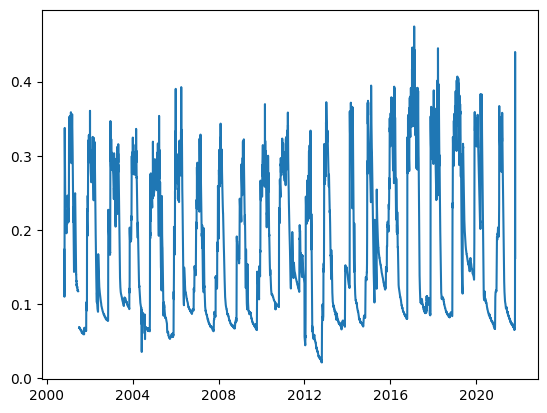

In [10]:
plt.plot(df['theta_2'])

## Gap-filling
![sample_data/Gap_filling_RF.PNG](https://github.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/blob/main/sample_data/Gap_filling_RF.PNG?raw=1)
**Credit**: Li *et al.* (2025), ESSD, https://doi.org/10.5194/essd-17-3835-2025

In [ ]:
try:
    from cuml.ensemble import RandomForestRegressor as cuRF
    GPU_AVAILABLE = True
except Exception:
    GPU_AVAILABLE = False
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
def add_lags(df, target, lags=(1, 3, 7)):
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    return df
def fill_gaps_RF(df, target):
    """Fill gaps using dual Random Forest models (CPU/GPU aware)"""
    df = add_lags(df, target)

    df_RF = df[np.isfinite(df[target])]
    if df_RF.empty:
        return df
    BASE_FEATURES_FLUX = ['TA_F','WS_F','VPD_F','SW_IN_F','LW_IN_F','PA_F','LAI','fPAR']
    LAG_FEATURES = [f'{target}_lag1',f'{target}_lag3',f'{target}_lag7']

    FEATURES_FLUX = BASE_FEATURES_FLUX + LAG_FEATURES

    y = df_RF[target].values

    X = df_RF[FEATURES_FLUX].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    #split = int(0.8 * len(X))
    #X_train, X_test = X[:split], X[split:]
    #y_train, y_test = y[:split], y[split:]
    # -------------------------
    # Model 1
    # -------------------------
    if GPU_AVAILABLE:
        RF1 = cuRF(n_estimators=100, max_depth=4)
    else:
        RF1 = RandomForestRegressor(
            n_estimators=100,
            max_depth=4,
            n_jobs=-1,
            random_state=42
        )

    RF1.fit(X_train, y_train)
    y_pred_train = RF1.predict(X_train)

    # -------------------------
    # Model 2 (Bias correction)
    # -------------------------
    Bias = y_train - y_pred_train
    X_bias = np.column_stack([X_train, y_pred_train])

    if GPU_AVAILABLE:
        RF2 = cuRF(n_estimators=100, max_depth=4)
    else:
        RF2 = RandomForestRegressor(
            n_estimators=100,
            max_depth=4,
            n_jobs=-1,
            random_state=42
        )

    RF2.fit(X_bias, Bias)

    # Evaluation
    y_pred_train = RF1.predict(X_train)
    Bias_train = RF2.predict(np.column_stack([X_train, y_pred_train]))
    y_final_train = y_pred_train + Bias_train
    rmse_train = root_mean_squared_error(y_train, y_final_train)
    r2_train = r2_score(y_train, y_final_train)

    y_pred_test = RF1.predict(X_test)
    Bias_test = RF2.predict(np.column_stack([X_test, y_pred_test]))
    y_final_test = y_pred_test + Bias_test

    rmse_test = root_mean_squared_error(y_test, y_final_test)
    r2_test = r2_score(y_test, y_final_test)
    print(f"{target} | "f"Train: R2={r2_train:.2f}, RMSE={rmse_train:.2f} | "f"Test: R2={r2_test:.2f}, RMSE={rmse_test:.2f}")
    # -------------------------
    # Gap filling
    # -------------------------
    mask = df[target].isna()
    if mask.sum() == 0:
        return df

    Xg = df.loc[mask, FEATURES_FLUX].values

    yp = RF1.predict(Xg)
    b = RF2.predict(np.column_stack([Xg, yp]))

    df.loc[mask, target] = yp + b
    metrics = {
        "target": target,
        "r2_train": r2_train,
        "rmse_train": rmse_train,
        "r2_test": r2_test,
        "rmse_test": rmse_test
    }
    return df, metrics

In [ ]:
df.iloc[[9, 23, 83], df.columns.get_loc('LE_F_MDS')] = np.nan
df.iloc[[9, 23, 83], df.columns.get_loc('PET')] = np.nan
site_metrics = []
for col in ['LE_F_MDS','PET']:
    if df[col].isna().sum() > 0:
        df, metrics = fill_gaps_RF(df, col)
        if metrics is not None:
                site_metrics.append(metrics)

LE_F_MDS | Train: R2=0.93, RMSE=6.56 | Test: R2=0.92, RMSE=6.99
PET | Train: R2=0.97, RMSE=6.80 | Test: R2=0.97, RMSE=7.21


In [ ]:
def detect_flash_droughts(df, ESR_column, site_name):
    """
    Identify flash drought events from a DataFrame with columns:
    ['Year', 'Pentad', 'ESR', 'SM', 'GPP', 'VPD', 'LE',....].

    Returns:
        events: list of dictionaries with event details, including mean SM, GPP, VPD, etc. during and outside the event.
        df: DataFrame with SESR values
    """
    df = df.copy()
    df['ESR'] = df[ESR_column]

    # --- Step 1: Calculate SESR (standardized ESR per pentad climatology) ---
    esr_stats = df.groupby('Pentad')['ESR'].agg(['mean', 'std']).reset_index()
    esr_stats.columns = ['Pentad', 'Mean_ESR', 'Std_ESR']
    esr_stats['Std_ESR'] = esr_stats['Std_ESR'].replace(0, np.nan)

    df = df.merge(esr_stats, on='Pentad')
    df['SESR'] = (df['ESR'] - df['Mean_ESR']) / df['Std_ESR']

    # --- Step 2: Calculate DSESR (change in SESR per pentad) ---
    df = df.sort_values(by=['Year', 'Pentad']).reset_index(drop=True)
    df['DSESR'] = df.groupby('Year')['SESR'].diff()

    # --- Standardize DSESR (pentad-wise) ---
    dsesr_stats = df.groupby('Pentad')['DSESR'].agg(['mean', 'std']).reset_index()
    dsesr_stats.columns = ['Pentad', 'Mean_DSESR', 'Std_DSESR']
    dsesr_stats['Std_DSESR'] = dsesr_stats['Std_DSESR'].replace(0, np.nan)

    df = df.merge(dsesr_stats, on='Pentad')
    df['DSESR_z'] = (df['DSESR'] - df['Mean_DSESR']) / df['Std_DSESR']


    # --- Step 3: Compute climatological percentiles ---
    sesr_20th = df.groupby('Pentad')['SESR'].apply(lambda x: np.percentile(x, 20)).to_dict()
    dsesr_40th = df.groupby('Pentad')['DSESR_z'].apply(lambda x: np.percentile(x, 40)).to_dict()
    df['SESR_20th'] = df['Pentad'].map(sesr_20th)
    df['DSESR_40th'] = df['Pentad'].map(dsesr_40th)

    events = []
    flash_pentads = set()
    flash_years = set()

    # --- Step 4: Loop through years ---
    for year in df['Year'].unique():
        sub = df[df['Year'] == year].reset_index(drop=True)
        i = 0
        while i < len(sub) - 5:
            seq = []
            j = i
            moderations = 0

            # Identify continuous sequence of DSESR <= 40th percentile
            while j < len(sub) - 1:
                if sub.loc[j + 1, 'DSESR_z'] <= sub.loc[j + 1, 'DSESR_40th']:
                    seq.append(j + 1)
                else:
                    # Allow one moderate break if next-next satisfies criteria
                    if moderations == 0:
                        if (j + 2 < len(sub) and
                            sub.loc[j + 2, 'DSESR_z'] <= sub.loc[j + 2, 'DSESR_40th'] and
                            sub.loc[j + 2, 'SESR'] < sub.loc[j, 'SESR']):
                            moderations += 1
                            seq.append(j + 2)
                            j += 1
                        else:
                            break
                    else:
                        break
                j += 1

            # --- Step 5: Apply flash drought criteria ---
            if len(seq) >= 5:
                end_idx = seq[-1]
                if sub.loc[end_idx, 'SESR'] < sub.loc[end_idx, 'SESR_20th']:
                    event_dsesr = sub.loc[seq, 'DSESR_z']
                    climatological_dsesr = df[df['Pentad'].isin(sub.loc[seq, 'Pentad'])]['DSESR_z'].dropna()
                    dsesr_25th = np.percentile(climatological_dsesr, 25)

                    if event_dsesr.mean() < dsesr_25th:
                        start_pentad = sub.loc[seq[0], 'Pentad']
                        end_pentad = sub.loc[end_idx, 'Pentad']

                        # Add pentads to flash-drought set
                        for p in range(start_pentad, end_pentad + 1):
                            flash_pentads.add((year, p))

                        flash_years.add(year)   # <-- NEW: year has flash drought

                        # --- Compute mean variables during and outside flash drought ---
                        mask_flash = (sub['Pentad'] > start_pentad) & (sub['Pentad'] < end_pentad-1)
                        mask_nonflash = sub['Pentad'].isin([start_pentad - 2, start_pentad - 3, start_pentad - 4, start_pentad - 5])

                        def mean_var(var):
                            return (
                                sub.loc[mask_flash, var].mean(),
                                sub.loc[mask_nonflash, var].mean()
                            )

                        sm_flash, sm_non = mean_var('SM')
                        le_flash, le_non = mean_var('LE')
                        srad_flash, srad_non = mean_var('SRad')
                        ef_flash, ef_non = mean_var('EF')
                        gc_flash, gc_non = mean_var('Gc_mol')
                        pet_flash, pet_non = mean_var('PET')

                        events.append({
                            'Year': year, 'Site': site_name,
                            'Start_Pentad': start_pentad-1, 'End_Pentad': end_pentad,
                            'Duration_Pentads': len(seq) + 1,
                            'SM_Flash': sm_flash, 'SM_NonFlash': sm_non,
                            'LE_Flash': le_flash, 'LE_NonFlash': le_non,
                            'SRad_Flash': srad_flash, 'SRad_NonFlash': srad_non,
                            'EF_Flash': ef_flash, 'EF_NonFlash': ef_non,
                            'Gc_Flash': gc_flash, 'Gc_NonFlash': gc_non,
                            'PET_Flash': pet_flash, 'PET_NonFlash': pet_non})
                i = end_idx + 1
            else:
                i += 1

    return events

In [ ]:
df_EC = df[['LE_F_MDS', 'H_F_MDS',  'theta_2', 'GPP_NT_VUT_REF', 'VPD_F', 'LAI', 'SW_IN_F', 'WS_F', 'TA_F', 'PA_F', 'PET']]
df_EC.columns = ['LE', 'H', 'SM', 'GPP', 'VPD', 'LAI', 'SRad', 'WS', 'TA', 'PA', 'PET']
df_EC = df_EC.copy()
df_EC['EF'] = df_EC['LE']/(df_EC['H'] + df_EC['LE'])  # Evaporative Fraction
df_EC.loc[(df_EC['EF'] < 0) | (df_EC['EF'] > 1), 'EF'] = np.nan
Cp = 1004.67      # Specific heat of air at constant pressure (J kg-1 K-1)
Rd = 287.058      # Specific gas constant for dry air (J kg-1 K-1)
R = 8.31447       # Universal gas constant (J mol-1 K-1)
epsilon = 0.622   # Ratio of molecular weight of water vapor to dry air

df_EC['rho_a'] = df_EC['PA'] * 1000 / (Rd * (df_EC['TA'] + 273.15)) # Air Density (kg m-3)
df_EC['lambda'] = (2.501 - 0.00236 * df_EC['TA']) * 1e6   # Latent heat of vaporization (J kg-1)
df_EC['gamma'] = (Cp * (df_EC['PA'])) / (epsilon * df_EC['lambda']) # Psychrometric constant (kPa K-1)

es = 0.611 * np.exp((17.27 * df_EC['TA']) / (df_EC['TA'] + 237.3))
df_EC['s'] = (4098 * es) / ((df_EC['TA'] + 237.3)**2) # Slope of saturation vapor pressure curve (kPa K-1)

df_EC['Ga'] =  df_EC['WS']/208
df_EC['beta'] = df_EC['H'] / df_EC['LE']       # Bowen Ratio (beta)
# Invert Penman-Monteith for Gc (m s-1) (https://www.sciencedirect.com/science/article/pii/S0168192325002692)
# 1/Gc = [(s/gamma) * beta - 1] * (1/Ga) + (rho_a * Cp * VPD) / (gamma * L * E)
term1 = ((df_EC['s'] / df_EC['gamma']) * df_EC['beta'] - 1) * (1 / df_EC['Ga'])
term2 = (df_EC['rho_a'] * Cp * (df_EC['VPD'])) / (df_EC['gamma'] * df_EC['LE'])

df_EC['inv_Gc'] = term1 + term2
df_EC['Gc_ms'] = 1 / df_EC['inv_Gc']
df_EC['Gc_mol'] = df_EC['Gc_ms'] * (df_EC['PA'] * 1000 / (R * (df_EC['TA'] + 273.15))) # Gc from m s-1 to mol m-2 s-1
df_EC['Gc_mol'] = df_EC['Gc_mol']/df_EC['LAI']
df_EC.loc[(df_EC['Gc_mol'] < 0) | (df_EC['Gc_mol'] > 100), 'Gc_mol'] = np.nan

# Daily Evaporative Stress Ratio (ESR) = ET/PET
df_EC['ESR'] = df_EC['LE']/df_EC['PET']
df_EC['ESR'] = np.clip(df_EC['ESR'] ,0,3)
df_EC = df_EC.reset_index()

In [ ]:
df_EC['Date'] = pd.to_datetime(df_EC['DateTime'])
df_EC = df_EC.drop(columns=['DateTime'])
df_EC['Year'] = df_EC['Date'].dt.year
df_EC['DoY']  = df_EC['Date'].dt.dayofyear.clip(upper=365)
df_EC['Pentad'] = ((df_EC['DoY'] - 1) // 5 + 1).astype(int)
df_pentad = df_EC.groupby(['Year', 'Pentad']).mean().reset_index()  # Pentad Mean
df_pentad.columns

Index(['Year', 'Pentad', 'LE', 'H', 'SM', 'GPP', 'VPD', 'LAI', 'SRad', 'WS',
       'TA', 'PA', 'PET', 'EF', 'rho_a', 'lambda', 'gamma', 's', 'Ga', 'beta',
       'inv_Gc', 'Gc_ms', 'Gc_mol', 'ESR', 'Date', 'DoY'],
      dtype='object')

In [ ]:
FD_events = detect_flash_droughts(df_pentad, "ESR", f'{site}')
FD_events = pd.DataFrame(FD_events)

df_anomaly = df_pentad[['Year', 'Pentad', 'ESR', 'SM', 'VPD', 'SRad', 'Gc_mol', 'EF']].copy()
clim = df_anomaly.groupby('Pentad').agg(Mean_ESR=('ESR', 'mean'), Std_ESR=('ESR', 'std'),
                                 Mean_SM=('SM', 'mean'), Std_SM=('SM', 'std'),
                                 Mean_VPD=('VPD', 'mean'), Std_VPD=('VPD', 'std'),
                                 Mean_SRad=('SRad', 'mean'), Std_SRad=('SRad', 'std'),
                                 Mean_Gc=('Gc_mol', 'mean'), Std_Gc=('Gc_mol', 'std'),
                                 Mean_EF=('EF', 'mean'), Std_EF=('EF', 'std')).reset_index()

df_anomaly = df_anomaly.merge(clim, on='Pentad', how='left')
df_anomaly['SESR'] = (df_anomaly['ESR'] - df_anomaly['Mean_ESR']) / df_anomaly['Std_ESR']      # ESR anomaly
df_anomaly['SSM']  = (df_anomaly['SM']  - df_anomaly['Mean_SM'])  / df_anomaly['Std_SM']       # SM anomaly
df_anomaly['SVPD'] = (df_anomaly['VPD'] - df_anomaly['Mean_VPD']) / df_anomaly['Std_VPD']      # GPP anomaly
df_anomaly['SSRad'] = (df_anomaly['SRad'] - df_anomaly['Mean_SRad']) / df_anomaly['Std_SRad']  # SRad anomaly
df_anomaly['SGc'] = (df_anomaly['Gc_mol'] - df_anomaly['Mean_Gc']) / df_anomaly['Std_Gc']      # Gc anomaly
df_anomaly['SEF'] = (df_anomaly['EF'] - df_anomaly['Mean_EF']) / df_anomaly['Std_EF']          # EF anomaly
df_anomaly['Mid_DoY'] = df_anomaly['Pentad'] * 5
df_anomaly['Site'] = site
df_anomaly

,Year,Pentad,ESR,SM,VPD,SRad,Gc_mol,EF,Mean_ESR,Std_ESR,...,Mean_EF,Std_EF,SESR,SSM,SVPD,SSRad,SGc,SEF,Mid_DoY,Site
0,2000,1,0.775626,NaN,2.210212,99.336238,0.035661,0.575234,0.938654,0.495374,...,0.596398,0.121197,-0.329100,NaN,-0.423816,0.644874,0.027234,-0.174626,5,US-Var
1,2000,2,0.925801,NaN,1.892400,84.230187,0.038353,0.563711,0.926270,0.569329,...,0.577451,0.128740,-0.000824,NaN,-0.154475,0.374514,-0.240334,-0.106722,10,US-Var
2,2000,3,0.735677,NaN,2.509313,56.457625,0.041950,0.598451,0.800260,0.417666,...,0.607900,0.154214,-0.154630,NaN,-0.018936,-1.097667,-0.246234,-0.061268,15,US-Var
3,2000,4,0.706062,NaN,1.024883,46.248104,0.284034,0.575234,0.908422,0.510820,...,0.606157,0.156661,-0.396147,NaN,-0.827100,-1.033145,1.348071,-0.197387,20,US-Var
4,2000,5,0.922248,NaN,0.851962,53.881108,0.093264,0.559028,0.933940,0.457529,...,0.614200,0.139343,-0.025555,NaN,-0.939728,-1.157434,0.715019,-0.395947,25,US-Var
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1601,2021,69,0.959151,NaN,1.145121,92.021092,0.062476,0.791032,0.828752,0.380061,...,0.628220,0.182261,0.343101,NaN,-1.061096,0.295279,1.164939,0.893291,345,US-Var
1602,2021,70,0.967415,NaN,1.505271,42.711892,0.138792,0.742951,0.941661,0.426756,...,0.669908,0.179331,0.060349,NaN,-1.036161,-1.443244,1.175619,0.407308,350,US-Var
1603,2021,71,1.021356,NaN,1.082325,106.026588,0.076424,0.776872,0.915373,0.339632,...,0.672587,0.145673,0.312053,NaN,-1.240170,0.976199,2.085654,0.715887,355,US-Var
1604,2021,72,0.993804,NaN,0.781221,39.046563,0.155759,0.791032,0.953419,0.491956,...,0.625409,0.105749,0.082091,NaN,-1.576977,-1.636407,3.605085,1.566195,360,US-Var


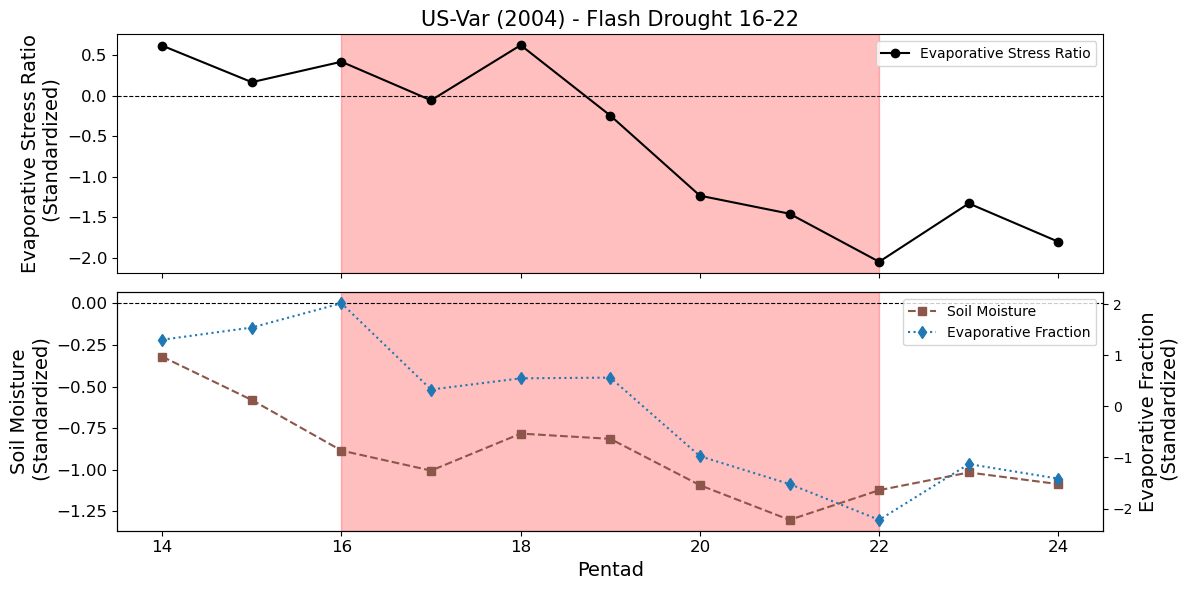

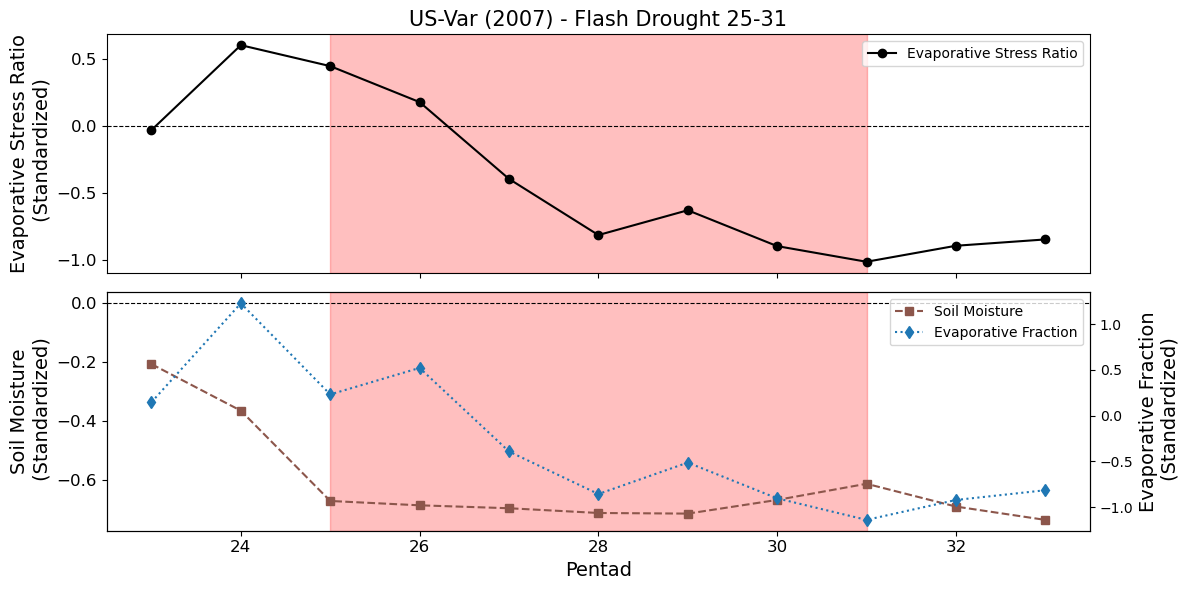

In [ ]:
def plot_event_sesr_sm(df_anomaly, site, year, start_p, end_p, window=2, savepath=None):
    import matplotlib.pyplot as plt
    import numpy as np

    p_min = max(1, start_p - window)
    p_max = min(73, end_p + window)

    data = df_anomaly[
        (df_anomaly['Site'] == site) &
        (df_anomaly['Year'] == year) &
        (df_anomaly['Pentad'] >= p_min) &
        (df_anomaly['Pentad'] <= p_max)
    ].copy().sort_values('Pentad')

    if data.empty:
        print(f"No data for {site}, {year}")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True)

    # SESR
    ax1.plot(data['Pentad'], data['SESR'],marker='o', color='black', label='Evaporative Stress Ratio')
    ax1.axvspan(start_p, end_p, alpha=0.25, color='red')
    ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax1.set_ylabel(f"Evaporative Stress Ratio\n (Standardized)", fontsize=14)
    ax1.set_title(f"{site} ({year}) - Flash Drought {start_p}-{end_p}",fontsize=15)
    ax1.legend()
    ax1.tick_params(labelsize=12)

    # Anomalies of Soil Moisture and Evaporative Fraction
    ax2.plot(data['Pentad'], data['SSM'],marker='s', linestyle='--',color='tab:brown', label='Soil Moisture')
    ax2.axvspan(start_p, end_p, alpha=0.25, color='red')
    ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax2.set_ylabel(f"Soil Moisture\n (Standardized)", fontsize=14)
    ax2.tick_params(labelsize=12)

    ax3 = ax2.twinx()
    ax3.plot(data['Pentad'], data['SEF'],marker='d', linestyle=':', color='tab:blue', label='Evaporative Fraction')
    ax3.set_ylabel(f"Evaporative Fraction\n (Standardized)", fontsize=14)

    lines = ax2.get_lines() + ax3.get_lines()
    lines = [l for l in lines if not l.get_label().startswith('_')]
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper right')
    ax2.set_xlabel("Pentad", fontsize=14)

    fig.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()
for _, ev in FD_events.iterrows():
    site    = ev['Site']
    year    = ev['Year']
    start_p = ev['Start_Pentad']
    end_p   = ev['End_Pentad']
    plot_event_sesr_sm(df_anomaly,site=site,year=year,start_p=start_p,end_p=end_p,window=2,savepath=None)